# Modifying previously published architectures

## ResNet50

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset, ConcatDataset
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, roc_auc_score
import torch

In [2]:
batch_size = 128
torch.manual_seed(0)
# dataset is RGB ie. 3 channels
# images in the dataset have varying sizes
# mean and std value used for normalisartion follows standard practice values of imagenet since ResNet that we are using is pretrained on imagenet
# ResNet50 req dimensions of images to be 224

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

train_dataset = datasets.Flowers102('data', split = 'train', download=True, transform = transform)
validation_dataset = datasets.Flowers102('data', split = 'val', download=True, transform = transform)
test_dataset = datasets.Flowers102('data', split = 'test', download=True, transform = transform)

torch.manual_seed(1)


100%|██████████| 345M/345M [00:20<00:00, 17.1MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.12MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 29.6MB/s]


In [4]:
torch.manual_seed(1)
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss <= self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, train_correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    train_loss /= num_batches
    train_correct /=size

    return train_loss, train_correct

def validation_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            val_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss /= num_batches
    val_correct /= size

    return val_loss, val_correct

Using device: cuda


In [7]:
# using the same train_loop in the previous cells
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            test_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_correct /= size

    return test_loss, test_correct

## Multi-layer Perceptron

In [8]:
model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 102)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = model.to(device)

lr = 0.0005 # optimal learning rate
num_epochs = 120 # increased no. of epochs since it might take longer time to converge

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=0.01)

patience = 5
early_stopper = EarlyStopper(patience=patience, min_delta=0.0001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


Using device: cuda


In [9]:
tr_losses, tr_accuracies = [], []
val_losses, val_accuracies = [], []

for t in range(num_epochs):
    model.train()
    train_loss, train_acc = train_loop(train_loader, model, loss_fn, optimizer)
    model.eval()
    val_loss, val_acc = validation_loop(validation_loader, model, loss_fn)

    tr_losses.append(train_loss)
    tr_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {t+1}: Train_accuracy: {(100*train_acc):>0.2f}%, Train_loss: {train_loss:>8f}, Validation_accuracy: {(100*val_acc):>0.2f}%, Validation_loss: {val_loss:>8f}")

    if early_stopper.early_stop(val_loss):
        print("Early stopping triggered!")
        break

Epoch 1: Train_accuracy: 1.47%, Train_loss: 4.644097, Validation_accuracy: 15.20%, Validation_loss: 4.429793
Epoch 2: Train_accuracy: 11.08%, Train_loss: 4.316716, Validation_accuracy: 35.10%, Validation_loss: 4.159234
Epoch 3: Train_accuracy: 22.75%, Train_loss: 4.005436, Validation_accuracy: 48.82%, Validation_loss: 3.797008
Epoch 4: Train_accuracy: 34.61%, Train_loss: 3.579911, Validation_accuracy: 57.65%, Validation_loss: 3.436283
Epoch 5: Train_accuracy: 42.75%, Train_loss: 3.190689, Validation_accuracy: 61.96%, Validation_loss: 3.081721
Epoch 6: Train_accuracy: 49.51%, Train_loss: 2.767254, Validation_accuracy: 63.92%, Validation_loss: 2.749391
Epoch 7: Train_accuracy: 59.80%, Train_loss: 2.391900, Validation_accuracy: 67.75%, Validation_loss: 2.444501
Epoch 8: Train_accuracy: 64.31%, Train_loss: 2.033124, Validation_accuracy: 73.04%, Validation_loss: 2.155597
Epoch 9: Train_accuracy: 67.35%, Train_loss: 1.757431, Validation_accuracy: 75.29%, Validation_loss: 1.928316
Epoch 10: T

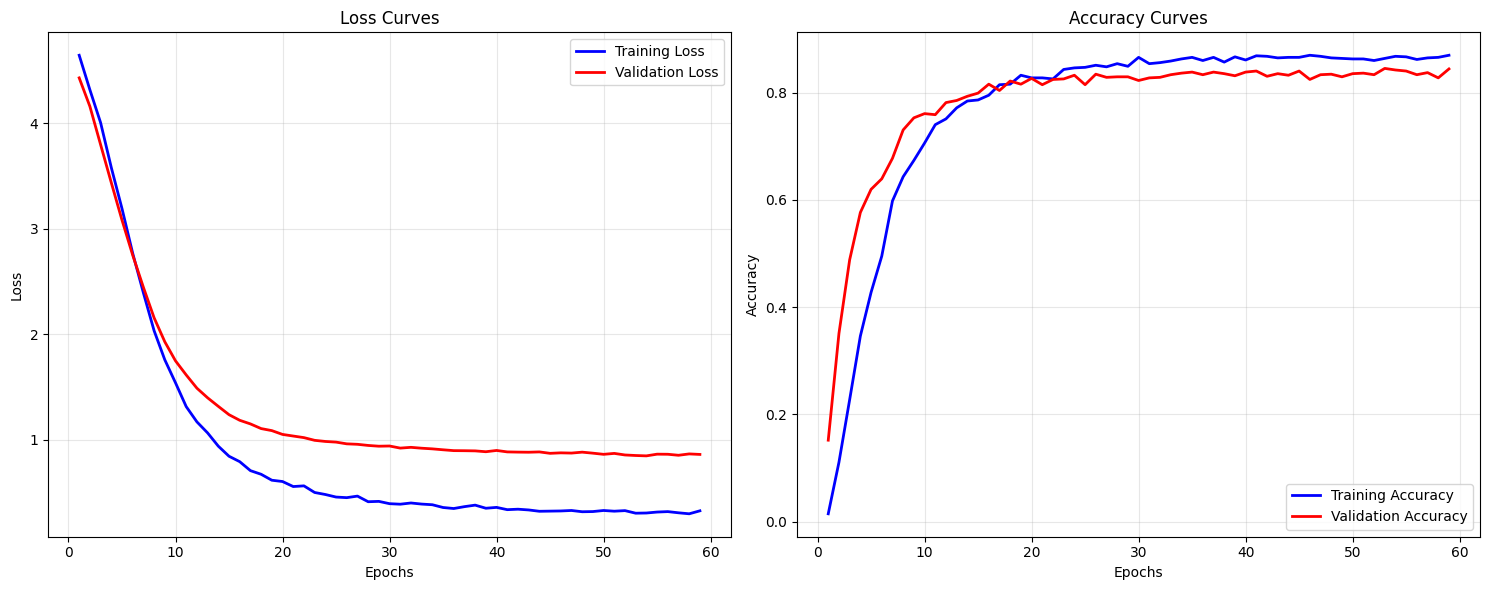

In [10]:
plt.figure(figsize=(15, 6))

# loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, len(tr_losses)+1), tr_losses, 'b-', linewidth=2, label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, 'r-', linewidth=2, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, len(tr_accuracies)+1), tr_accuracies, 'b-', linewidth=2, label='Training Accuracy')
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, 'r-', linewidth=2, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
#evaluating on test set
loss_fn = nn.CrossEntropyLoss()

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

test_loss, test_accuracy = test_loop(test_loader, model, loss_fn)

print("\n" + "="*50)
print("TEST SET EVALUATION RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Correct predictions: {int(test_accuracy * len(test_dataset))}/{len(test_dataset)}")


TEST SET EVALUATION RESULTS
Test Loss: 0.9389
Test Accuracy: 81.44%
Correct predictions: 5008/6149
